# Modèles de deep learning

Dans ce notebook, nous évaluons quatre modèles Transformers préentraînés
pour la détection des faux avis Amazon :
- BERT ;
- DistilBERT ;
- RoBERTa ;
- DistilRoBERTa.

Les données sont séparées en trois ensembles : 70 % pour l’entraînement, 10 % pour la validation et 20 % pour le test.

Une évaluation est réalisée sur l'ensemble de validation à la fin de chaque
époque, et le checkpoint présentant le meilleur F1-score est conservé pour
l'évaluation finale.

Les modèles retenus sont ensuite évalués sur l'ensemble de test à l'aide de
l'exactitude, de la précision, du rappel, du F1-score et de la PR-AUC.
Une matrice de confusion et une courbe précision-rappel sont également
présentées pour chaque modèle.

Enfin, les performances et les temps de fine-tuning des quatre modèles sont
comparés.

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    confusion_matrix,
    precision_recall_curve
)

import torch
from torch.utils.data import Dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding
)

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 200)

## Chargement du dataset prétraité

Nous chargeons le dataset prétraité généré dans le notebook `02_pretraitement_textes.ipynb`. Il contient les avis originaux, leur version prétraitée, le statut d’achat vérifié, la longueur des avis, ainsi que les labels textuel et numérique.

In [3]:
from pathlib import Path
import socket

HOSTNAME = socket.gethostname()

PROJECT_DIR = (
    Path.home() / "amazon_reviews_experimentation"
    if HOSTNAME == "cybernemo-main-worker-GPU1"
    else Path.cwd().parent
)

DATA_DIR = PROJECT_DIR / "data"
OUTPUTS_DIR = PROJECT_DIR / "outputs"
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

file_path = DATA_DIR / "amazon_reviews_preprocessed.csv"

print("Machine :", HOSTNAME)
print("Dossier du projet :", PROJECT_DIR)
print("Fichier utilisé :", file_path)

df = pd.read_csv(file_path)
df.head()

Machine : cybernemo-main-worker-GPU1
Dossier du projet : /home/siham/amazon_reviews_experimentation
Fichier utilisé : /home/siham/amazon_reviews_experimentation/data/amazon_reviews_preprocessed.csv


,DOC_ID,REVIEW_TEXT,preprocessed_text,VERIFIED_PURCHASE,review_word_count,LABEL,label_num
0,1,"When least you think so, this product will save the day. Just keep it around just in case you need it for something.",least think product save day keep around case need someth,N,23,fake,1
1,2,Lithium batteries are something new introduced in the market there average developing cost is relatively high but Stallion doesn't compromise on quality and provides us with the best at a low cost...,lithium batteri someth new introduc market averag develop cost rel high stallion compromis qualiti provid us best low cost br mani built technic assist act like sensor particular fort batteri keep...,Y,69,fake,1
2,3,I purchased this swing for my baby. She is 6 months now and has pretty much out grown it. It is very loud and doesn't swing very well. It is beautiful though. I love the colors and it has a lot of...,purchas swing babi 6 month pretti much grown loud swing well beauti though love color lot set think worth money,N,52,fake,1
3,4,I was looking for an inexpensive desk calcolatur and here it is. It works and does everything I need. Only issue is that it tilts slightly to one side so when I hit any keys it rocks a little bit....,look inexpens desk calcolatur work everyth need issu tilt slightli one side hit key rock littl bit big deal,N,44,fake,1
4,5,"I only use it twice a week and the results are great. I have used other teeth whitening solutions and most of them, for the same results I would have to use it at least three times a week. Will ke...",use twice week result great use teeth whiten solut result would use least three time week keep use potenc solut also techniqu tray keep everyth teeth mouth,N,66,fake,1


## Séparation des données en ensembles d’entraînement, de validation et de test

Les données sont séparées en trois ensembles :

- un ensemble d’entraînement utilisé pour ajuster les paramètres des modèles ;
- un ensemble de validation utilisé pour suivre les performances pendant l’entraînement et sélectionner le meilleur modèle ;
- un ensemble de test réservé à l’évaluation finale.

Les modèles Transformers sont entraînés à partir des avis originaux contenus dans la colonne `REVIEW_TEXT`. Cette approche permet de conserver la ponctuation, les mots-outils et la structure des phrases, qui peuvent fournir des informations utiles aux modèles préentraînés.

La séparation est stratifiée afin de conserver la proportion des avis authentiques et des faux avis dans chaque ensemble.

In [4]:
X = df["REVIEW_TEXT"].astype(str)
y = df["label_num"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=2/3,
    random_state=42,
    stratify=y_temp
)
print(f"Ensemble d'entraînement : {len(X_train)} avis")
print(f"Ensemble de validation   : {len(X_val)} avis")
print(f"Ensemble de test         : {len(X_test)} avis")

Ensemble d'entraînement : 14700 avis
Ensemble de validation   : 2100 avis
Ensemble de test         : 4200 avis


## Préparation des données pour les modèles Transformers

Chaque modèle Transformer utilise son propre tokenizer pour convertir les avis en séquences de tokens. Afin d’éviter de répéter la même logique pour les quatre modèles, nous définissons une classe `Dataset` générique qui reçoit les textes, les labels et le tokenizer associé au modèle étudié.

La tokenisation applique une troncature aux avis dépassant la longueur maximale fixée à 256 tokens. Le remplissage (padding) est ensuite réalisé dynamiquement au niveau de chaque lot.

In [5]:
class ReviewsDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=256):
        self.texts = texts.reset_index(drop=True)
        self.labels = labels.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, index):
        encoding = self.tokenizer(
            self.texts.iloc[index],
            truncation=True,
            max_length=self.max_length
        )
        encoding["labels"] = int(self.labels.iloc[index])
        return encoding

## Définition des métriques d’évaluation

Les performances des modèles sont évaluées à l’aide de l’exactitude, de la précision, du rappel, du F1-score et de la PR-AUC. Une fonction commune est définie afin d’appliquer le même protocole d’évaluation aux quatre modèles Transformers.

In [6]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probabilities = torch.softmax(
        torch.tensor(logits), dim=1
    ).numpy()[:, 1]
    predictions = np.argmax(logits, axis=1)

    return {
        "accuracy": accuracy_score(labels, predictions),
        "precision": precision_score(labels, predictions, zero_division=0),
        "recall": recall_score(labels, predictions, zero_division=0),
        "f1": f1_score(labels, predictions, zero_division=0),
        "pr_auc": average_precision_score(labels, probabilities)
    }

## BERT

BERT est le premier modèle Transformer évalué dans ce notebook. Nous utilisons la version préentraînée `bert-base-uncased`, adaptée à une tâche de classification binaire afin de distinguer les avis authentiques des faux avis.

Le tokenizer associé au modèle est chargé, puis les ensembles d’entraînement, de validation et de test sont convertis en objets `Dataset`.

In [7]:
bert_model_name = "bert-base-uncased"
bert_tokenizer = AutoTokenizer.from_pretrained(bert_model_name)
# Création des datasets
bert_train_dataset = ReviewsDataset(X_train, y_train, bert_tokenizer)
bert_val_dataset = ReviewsDataset(X_val, y_val, bert_tokenizer)
bert_test_dataset = ReviewsDataset(X_test, y_test, bert_tokenizer)
# Remplissage dynamique des séquences
bert_data_collator = DataCollatorWithPadding(tokenizer=bert_tokenizer)

print("Nombre d'avis d'entraînement :", len(bert_train_dataset))
print("Nombre d'avis de validation   :", len(bert_val_dataset))
print("Nombre d'avis de test         :", len(bert_test_dataset))

Nombre d'avis d'entraînement : 14700
Nombre d'avis de validation   : 2100
Nombre d'avis de test         : 4200


### Configuration et fine-tuning du modèle

Le modèle préentraîné `bert-base-uncased` est chargé avec une tête de classification binaire. Les paramètres du fine-tuning sont ensuite définis, puis le `Trainer` est configuré à partir des ensembles d’entraînement et de validation. À la fin de chaque époque, les performances sont mesurées sur l’ensemble de validation et le meilleur checkpoint est sélectionné selon le score F1.

In [8]:
# Chargement du modèle
bert_model = AutoModelForSequenceClassification.from_pretrained(
    bert_model_name, num_labels=2
)
# Paramètres du fine-tuning
bert_training_args = TrainingArguments(
    output_dir=str(OUTPUTS_DIR / "bert"),
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    logging_strategy="epoch",
    fp16=True,
    report_to="none"
)
# Configuration du Trainer
bert_trainer = Trainer(
    model=bert_model,
    args=bert_training_args,
    train_dataset=bert_train_dataset,
    eval_dataset=bert_val_dataset,
    data_collator=bert_data_collator,
    compute_metrics=compute_metrics
)
# Fine-tuning
bert_train_result = bert_trainer.train()

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Pr Auc
1,0.615600,0.560125,0.710476,0.681148,0.791429,0.732159,0.783197
2,0.476600,0.557490,0.725714,0.740854,0.694286,0.716814,0.800755
3,0.307700,0.668752,0.722857,0.741736,0.683810,0.711596,0.795019


### Évaluation sur le jeu de test

In [9]:
# Prédictions sur l'ensemble de test
bert_test_output = bert_trainer.predict(bert_test_dataset)

bert_logits = bert_test_output.predictions
bert_y_true = bert_test_output.label_ids
bert_y_pred = np.argmax(bert_logits, axis=1)

bert_y_prob = torch.softmax(
    torch.tensor(bert_logits), dim=1
).numpy()[:, 1]
# Calcul des métriques
bert_metrics = pd.DataFrame({
    "Métrique": ["Exactitude", "Précision", "Rappel", "F1-score", "PR-AUC"],
    "Valeur": [
        accuracy_score(bert_y_true, bert_y_pred),
        precision_score(bert_y_true, bert_y_pred, zero_division=0),
        recall_score(bert_y_true, bert_y_pred, zero_division=0),
        f1_score(bert_y_true, bert_y_pred, zero_division=0),
        average_precision_score(bert_y_true, bert_y_prob)
    ]
})
bert_metrics["Valeur"] = bert_metrics["Valeur"].round(4)
bert_metrics

,Métrique,Valeur
0,Exactitude,0.6893
1,Précision,0.6603
2,Rappel,0.7795
3,F1-score,0.7150
4,PR-AUC,0.7675


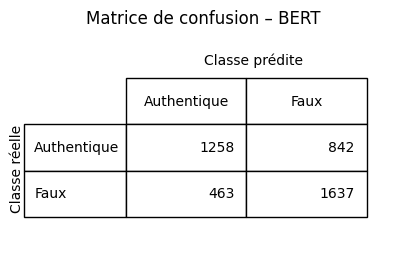

In [10]:
# Matrice de confusion
bert_cm = confusion_matrix(bert_y_true, bert_y_pred)

fig, ax = plt.subplots(figsize=(5, 3))
ax.axis("off")
ax.table(
    cellText=bert_cm,
    rowLabels=["Authentique", "Faux"],
    colLabels=["Authentique", "Faux"],
    bbox=[0.30, 0.20, 0.62, 0.60]
)
ax.text(0.50, 0.86, "Classe prédite")
ax.text(0, 0.23, "Classe réelle", rotation=90)
plt.title("Matrice de confusion – BERT")
plt.show()

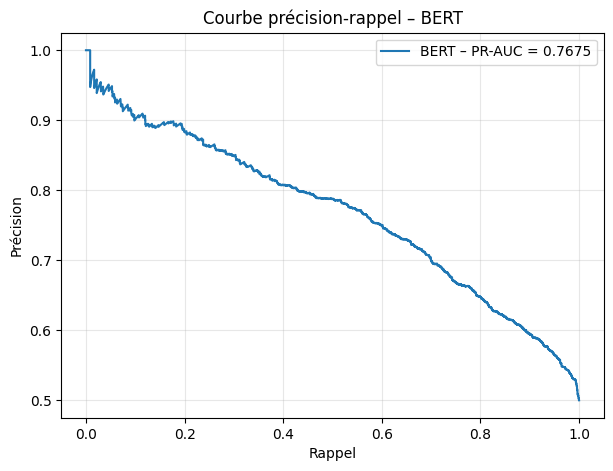

In [11]:
# Courbe précision-rappel
bert_precision_curve, bert_recall_curve, _ = precision_recall_curve(
    bert_y_true, bert_y_prob
)
bert_pr_auc = average_precision_score(bert_y_true, bert_y_prob)

plt.figure(figsize=(7, 5))
plt.plot(
    bert_recall_curve,
    bert_precision_curve,
    label=f"BERT – PR-AUC = {bert_pr_auc:.4f}"
)
plt.xlabel("Rappel")
plt.ylabel("Précision")
plt.title("Courbe précision-rappel – BERT")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## DistilBERT

DistilBERT est une version distillée de BERT conçue pour réduire le nombre de paramètres et le coût computationnel tout en conservant une grande partie de ses performances.

Nous utilisons la version préentraînée `distilbert-base-uncased`, adaptée à une tâche de classification binaire. Le tokenizer associé est chargé, puis les ensembles d’entraînement, de validation et de test sont convertis en objets `Dataset`.

In [12]:
distilbert_model_name = "distilbert-base-uncased"
distilbert_tokenizer = AutoTokenizer.from_pretrained(distilbert_model_name)
# Création des datasets
distilbert_train_dataset = ReviewsDataset(X_train, y_train, distilbert_tokenizer)
distilbert_val_dataset = ReviewsDataset(X_val, y_val, distilbert_tokenizer)
distilbert_test_dataset = ReviewsDataset(X_test, y_test, distilbert_tokenizer)
# Remplissage dynamique des séquences
distilbert_data_collator = DataCollatorWithPadding(tokenizer=distilbert_tokenizer)

### Configuration et fine-tuning du modèle

Le modèle préentraîné `distilbert-base-uncased` est chargé avec une tête de classification binaire. Les paramètres du fine-tuning sont ensuite définis, puis le `Trainer` est configuré à partir des ensembles d’entraînement et de validation. À la fin de chaque époque, les performances sont mesurées sur l’ensemble de validation et le meilleur checkpoint est sélectionné selon le score F1.

In [13]:
# Chargement du modèle
distilbert_model = AutoModelForSequenceClassification.from_pretrained(
    distilbert_model_name, num_labels=2
)
# Paramètres du fine-tuning
distilbert_training_args = TrainingArguments(
    output_dir=str(OUTPUTS_DIR / "distilbert"),
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    logging_strategy="epoch",
    fp16=True,
    report_to="none"
)
# Configuration du Trainer
distilbert_trainer = Trainer(
    model=distilbert_model,
    args=distilbert_training_args,
    train_dataset=distilbert_train_dataset,
    eval_dataset=distilbert_val_dataset,
    data_collator=distilbert_data_collator,
    compute_metrics=compute_metrics
)
# Fine-tuning
distilbert_train_result = distilbert_trainer.train()

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Pr Auc
1,0.613900,0.564836,0.712381,0.695958,0.754286,0.723949,0.777642
2,0.506200,0.555059,0.727619,0.725472,0.732381,0.728910,0.791852
3,0.392000,0.603319,0.719048,0.719048,0.719048,0.719048,0.787133


### Évaluation sur le jeu de test

In [14]:
# Prédictions sur l'ensemble de test
distilbert_test_output = distilbert_trainer.predict(distilbert_test_dataset)

distilbert_logits = distilbert_test_output.predictions
distilbert_y_true = distilbert_test_output.label_ids
distilbert_y_pred = np.argmax(distilbert_logits, axis=1)

distilbert_y_prob = torch.softmax(
    torch.tensor(distilbert_logits), dim=1
).numpy()[:, 1]
# Calcul des métriques
distilbert_metrics = pd.DataFrame({
    "Métrique": ["Exactitude", "Précision", "Rappel", "F1-score", "PR-AUC"],
    "Valeur": [
        accuracy_score(distilbert_y_true, distilbert_y_pred),
        precision_score(distilbert_y_true, distilbert_y_pred, zero_division=0),
        recall_score(distilbert_y_true, distilbert_y_pred, zero_division=0),
        f1_score(distilbert_y_true, distilbert_y_pred, zero_division=0),
        average_precision_score(distilbert_y_true, distilbert_y_prob)
    ]
})
distilbert_metrics["Valeur"] = distilbert_metrics["Valeur"].round(4)
distilbert_metrics

,Métrique,Valeur
0,Exactitude,0.7014
1,Précision,0.6937
2,Rappel,0.7214
3,F1-score,0.7073
4,PR-AUC,0.7684


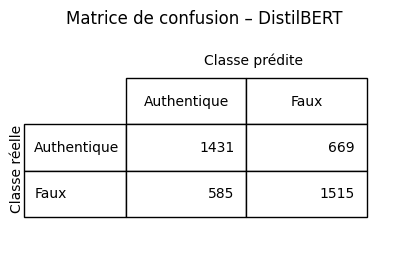

In [15]:
# Matrice de confusion
distilbert_cm = confusion_matrix(distilbert_y_true, distilbert_y_pred)

fig, ax = plt.subplots(figsize=(5, 3))
ax.axis("off")
ax.table(
    cellText=distilbert_cm,
    rowLabels=["Authentique", "Faux"],
    colLabels=["Authentique", "Faux"],
    bbox=[0.30, 0.20, 0.62, 0.60]
)
ax.text(0.50, 0.86, "Classe prédite")
ax.text(0, 0.23, "Classe réelle", rotation=90)
plt.title("Matrice de confusion – DistilBERT")
plt.show()

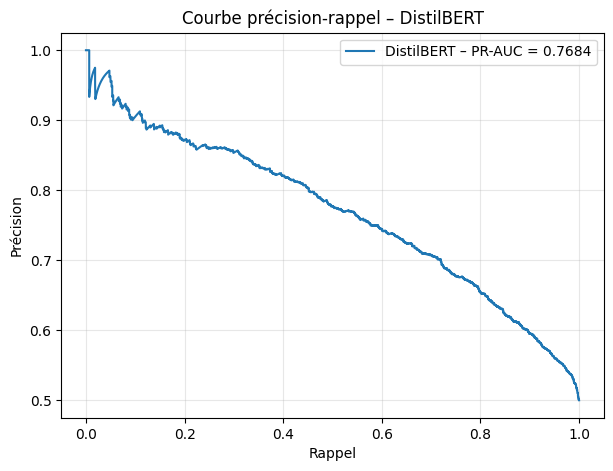

In [16]:
# Courbe précision-rappel
distilbert_precision_curve, distilbert_recall_curve, _ = precision_recall_curve(
    distilbert_y_true, distilbert_y_prob
)
distilbert_pr_auc = average_precision_score(
    distilbert_y_true, distilbert_y_prob
)
plt.figure(figsize=(7, 5))
plt.plot(
    distilbert_recall_curve,
    distilbert_precision_curve,
    label=f"DistilBERT – PR-AUC = {distilbert_pr_auc:.4f}"
)
plt.xlabel("Rappel")
plt.ylabel("Précision")
plt.title("Courbe précision-rappel – DistilBERT")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## RoBERTa

RoBERTa est une variante optimisée de BERT, préentraînée avec une stratégie d’apprentissage modifiée et sur un volume de données plus important. Contrairement à BERT et DistilBERT, son tokenizer repose sur la méthode Byte-Pair Encoding.

Nous utilisons la version préentraînée `roberta-base`, adaptée à une tâche de classification binaire. Le tokenizer associé est chargé, puis les ensembles d’entraînement, de validation et de test sont convertis en objets `Dataset`.

In [17]:
roberta_model_name = "roberta-base"
roberta_tokenizer = AutoTokenizer.from_pretrained(roberta_model_name)
# Création des datasets
roberta_train_dataset = ReviewsDataset(X_train, y_train, roberta_tokenizer)
roberta_val_dataset = ReviewsDataset(X_val, y_val, roberta_tokenizer)
roberta_test_dataset = ReviewsDataset(X_test, y_test, roberta_tokenizer)
# Remplissage dynamique des séquences
roberta_data_collator = DataCollatorWithPadding(tokenizer=roberta_tokenizer)

### Configuration et fine-tuning du modèle

Le modèle préentraîné `roberta-base` est chargé avec une tête de classification binaire. Les paramètres du fine-tuning sont ensuite définis, puis le `Trainer` est configuré à partir des ensembles d’entraînement et de validation. À la fin de chaque époque, les performances sont mesurées sur l’ensemble de validation et le meilleur checkpoint est sélectionné selon le score F1.

In [18]:
# Chargement du modèle
roberta_model = AutoModelForSequenceClassification.from_pretrained(
    roberta_model_name, num_labels=2
)
# Paramètres du fine-tuning
roberta_training_args = TrainingArguments(
    output_dir=str(OUTPUTS_DIR / "roberta"),
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    logging_strategy="epoch",
    fp16=True,
    report_to="none"
)
# Configuration du Trainer
roberta_trainer = Trainer(
    model=roberta_model,
    args=roberta_training_args,
    train_dataset=roberta_train_dataset,
    eval_dataset=roberta_val_dataset,
    data_collator=roberta_data_collator,
    compute_metrics=compute_metrics
)
# Fine-tuning
roberta_train_result = roberta_trainer.train()

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Pr Auc
1,0.578600,0.518287,0.750476,0.759881,0.732381,0.745878,0.829402
2,0.478000,0.497908,0.759048,0.782744,0.717143,0.748509,0.839612
3,0.369300,0.534799,0.764286,0.770204,0.753333,0.761675,0.840288


### Évaluation sur le jeu de test

In [19]:
# Prédictions sur l'ensemble de test
roberta_test_output = roberta_trainer.predict(roberta_test_dataset)

roberta_logits = roberta_test_output.predictions
roberta_y_true = roberta_test_output.label_ids
roberta_y_pred = np.argmax(roberta_logits, axis=1)

roberta_y_prob = torch.softmax(
    torch.tensor(roberta_logits), dim=1
).numpy()[:, 1]
# Calcul des métriques
roberta_metrics = pd.DataFrame({
    "Métrique": ["Exactitude", "Précision", "Rappel", "F1-score", "PR-AUC"],
    "Valeur": [
        accuracy_score(roberta_y_true, roberta_y_pred),
        precision_score(roberta_y_true, roberta_y_pred, zero_division=0),
        recall_score(roberta_y_true, roberta_y_pred, zero_division=0),
        f1_score(roberta_y_true, roberta_y_pred, zero_division=0),
        average_precision_score(roberta_y_true, roberta_y_prob)
    ]
})
roberta_metrics["Valeur"] = roberta_metrics["Valeur"].round(4)
roberta_metrics

,Métrique,Valeur
0,Exactitude,0.7450
1,Précision,0.7477
2,Rappel,0.7395
3,F1-score,0.7436
4,PR-AUC,0.8286


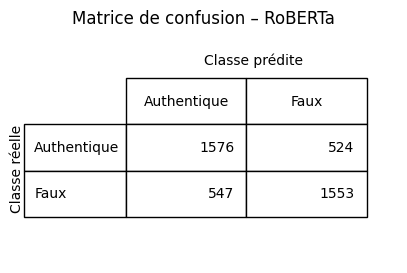

In [20]:
# Matrice de confusion
roberta_cm = confusion_matrix(roberta_y_true, roberta_y_pred)

fig, ax = plt.subplots(figsize=(5, 3))
ax.axis("off")
ax.table(
    cellText=roberta_cm,
    rowLabels=["Authentique", "Faux"],
    colLabels=["Authentique", "Faux"],
    bbox=[0.30, 0.20, 0.62, 0.60]
)
ax.text(0.50, 0.86, "Classe prédite")
ax.text(0, 0.23, "Classe réelle", rotation=90)
plt.title("Matrice de confusion – RoBERTa")
plt.show()

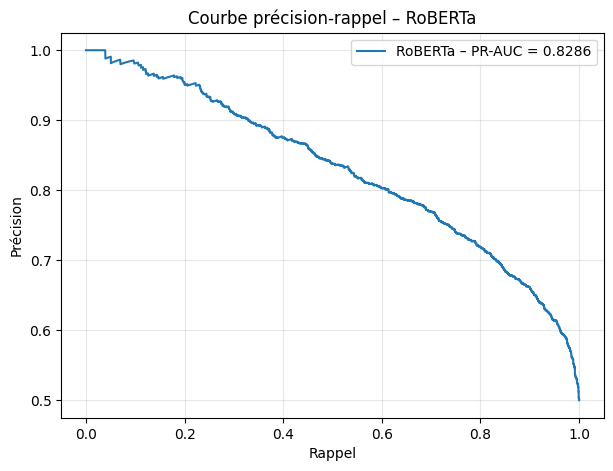

In [21]:
# Courbe précision-rappel
roberta_precision_curve, roberta_recall_curve, _ = precision_recall_curve(
    roberta_y_true, roberta_y_prob
)
roberta_pr_auc = average_precision_score(roberta_y_true, roberta_y_prob)
plt.figure(figsize=(7, 5))
plt.plot(
    roberta_recall_curve,
    roberta_precision_curve,
    label=f"RoBERTa – PR-AUC = {roberta_pr_auc:.4f}"
)
plt.xlabel("Rappel")
plt.ylabel("Précision")
plt.title("Courbe précision-rappel – RoBERTa")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## DistilRoBERTa

DistilRoBERTa est une version distillée de RoBERTa conçue pour réduire le nombre de paramètres et le coût computationnel tout en conservant une grande partie de ses performances. Comme RoBERTa, son tokenizer repose sur la méthode Byte-Pair Encoding.

Nous utilisons la version préentraînée `distilbert/distilroberta-base`, adaptée à une tâche de classification binaire. Le tokenizer associé est chargé, puis les ensembles d’entraînement, de validation et de test sont convertis en objets `Dataset`.

In [22]:
distilroberta_model_name = "distilbert/distilroberta-base"
distilroberta_tokenizer = AutoTokenizer.from_pretrained(distilroberta_model_name)
# Création des datasets
distilroberta_train_dataset = ReviewsDataset(X_train, y_train, distilroberta_tokenizer)
distilroberta_val_dataset = ReviewsDataset(X_val, y_val, distilroberta_tokenizer)
distilroberta_test_dataset = ReviewsDataset(X_test, y_test, distilroberta_tokenizer)
# Remplissage dynamique des séquences
distilroberta_data_collator = DataCollatorWithPadding(
    tokenizer=distilroberta_tokenizer
)

### Configuration et fine-tuning du modèle

Le modèle préentraîné `distilbert/distilroberta-base` est chargé avec une tête de classification binaire. Les paramètres du fine-tuning sont ensuite définis, puis le `Trainer` est configuré à partir des ensembles d’entraînement et de validation. À la fin de chaque époque, les performances sont mesurées sur l’ensemble de validation et le meilleur checkpoint est sélectionné selon le score F1.

In [23]:
# Chargement du modèle
distilroberta_model = AutoModelForSequenceClassification.from_pretrained(
    distilroberta_model_name,
    num_labels=2
)
# Paramètres du fine-tuning
distilroberta_training_args = TrainingArguments(
    output_dir=str(OUTPUTS_DIR / "distilroberta"),
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    logging_strategy="epoch",
    fp16=True,
    report_to="none"
)
# Configuration du Trainer
distilroberta_trainer = Trainer(
    model=distilroberta_model,
    args=distilroberta_training_args,
    train_dataset=distilroberta_train_dataset,
    eval_dataset=distilroberta_val_dataset,
    data_collator=distilroberta_data_collator,
    compute_metrics=compute_metrics
)
# Fine-tuning
distilroberta_train_result = distilroberta_trainer.train()

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at distilbert/distilroberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Pr Auc
1,0.580200,0.525039,0.746190,0.733937,0.772381,0.752668,0.811147
2,0.497600,0.499948,0.758571,0.759809,0.756190,0.757995,0.828274
3,0.421200,0.533766,0.755714,0.736148,0.797143,0.765432,0.833009


### Évaluation sur le jeu de test

In [24]:
# Prédictions sur l'ensemble de test
distilroberta_test_output = distilroberta_trainer.predict(
    distilroberta_test_dataset
)

distilroberta_logits = distilroberta_test_output.predictions
distilroberta_y_true = distilroberta_test_output.label_ids
distilroberta_y_pred = np.argmax(distilroberta_logits, axis=1)

distilroberta_y_prob = torch.softmax(
    torch.tensor(distilroberta_logits), dim=1
).numpy()[:, 1]
# Calcul des métriques
distilroberta_metrics = pd.DataFrame({
    "Métrique": ["Exactitude", "Précision", "Rappel", "F1-score", "PR-AUC"],
    "Valeur": [
        accuracy_score(distilroberta_y_true, distilroberta_y_pred),
        precision_score(
            distilroberta_y_true, distilroberta_y_pred, zero_division=0
        ),
        recall_score(
            distilroberta_y_true, distilroberta_y_pred, zero_division=0
        ),
        f1_score(
            distilroberta_y_true, distilroberta_y_pred, zero_division=0
        ),
        average_precision_score(
            distilroberta_y_true, distilroberta_y_prob
        )
    ]
})
distilroberta_metrics["Valeur"] = distilroberta_metrics["Valeur"].round(4)
distilroberta_metrics

,Métrique,Valeur
0,Exactitude,0.7352
1,Précision,0.7186
2,Rappel,0.7733
3,F1-score,0.7450
4,PR-AUC,0.8128


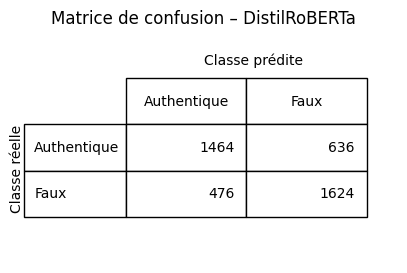

In [25]:
# Matrice de confusion
distilroberta_cm = confusion_matrix(distilroberta_y_true, distilroberta_y_pred)

fig, ax = plt.subplots(figsize=(5, 3))
ax.axis("off")
ax.table(
    cellText=distilroberta_cm,
    rowLabels=["Authentique", "Faux"],
    colLabels=["Authentique", "Faux"],
    bbox=[0.30, 0.20, 0.62, 0.60]
)
ax.text(0.50, 0.86, "Classe prédite")
ax.text(0, 0.23, "Classe réelle", rotation=90)
plt.title("Matrice de confusion – DistilRoBERTa")
plt.show()

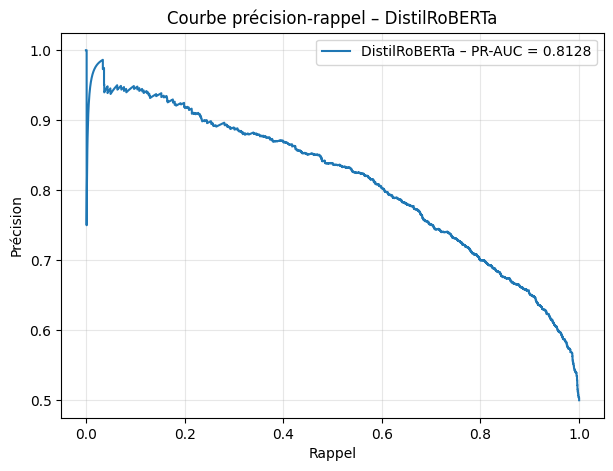

In [26]:
# Courbe précision-rappel
distilroberta_precision_curve, distilroberta_recall_curve, _ = precision_recall_curve(
    distilroberta_y_true, distilroberta_y_prob
)
distilroberta_pr_auc = average_precision_score(
    distilroberta_y_true, distilroberta_y_prob
)
plt.figure(figsize=(7, 5))
plt.plot(
    distilroberta_recall_curve,
    distilroberta_precision_curve,
    label=f"DistilRoBERTa – PR-AUC = {distilroberta_pr_auc:.4f}"
)
plt.xlabel("Rappel")
plt.ylabel("Précision")
plt.title("Courbe précision-rappel – DistilRoBERTa")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Temps de fine-tuning

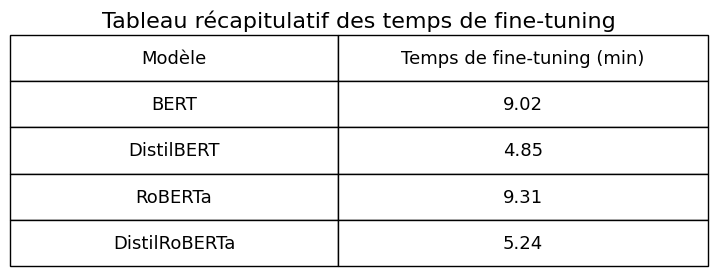

In [27]:
# Tableau récapitulatif des temps de fine-tuning
training_times_dl = pd.DataFrame({
    "Modèle": ["BERT", "DistilBERT", "RoBERTa", "DistilRoBERTa"],
    "Temps de fine-tuning (min)": [
        bert_train_result.metrics["train_runtime"] / 60,
        distilbert_train_result.metrics["train_runtime"] / 60,
        roberta_train_result.metrics["train_runtime"] / 60,
        distilroberta_train_result.metrics["train_runtime"] / 60
    ]
})
training_times_dl["Temps de fine-tuning (min)"] = (
    training_times_dl["Temps de fine-tuning (min)"].round(2)
)
training_times_dl

fig, ax = plt.subplots(figsize=(9, 3))
ax.axis("off")
table = ax.table(
    cellText=training_times_dl.values,
    colLabels=training_times_dl.columns,
    cellLoc="center",
    bbox=[0, 0, 1, 1],
    colWidths=[0.40, 0.45]
)
table.auto_set_font_size(False)
table.set_fontsize(13)
plt.title("Tableau récapitulatif des temps de fine-tuning", fontsize=16)
plt.show()

## Comparaison des modèles

Les performances de BERT, DistilBERT, RoBERTa et DistilRoBERTa sont regroupées afin de faciliter leur comparaison. Les modèles sont évalués selon les mêmes métriques et sur le même ensemble de test.

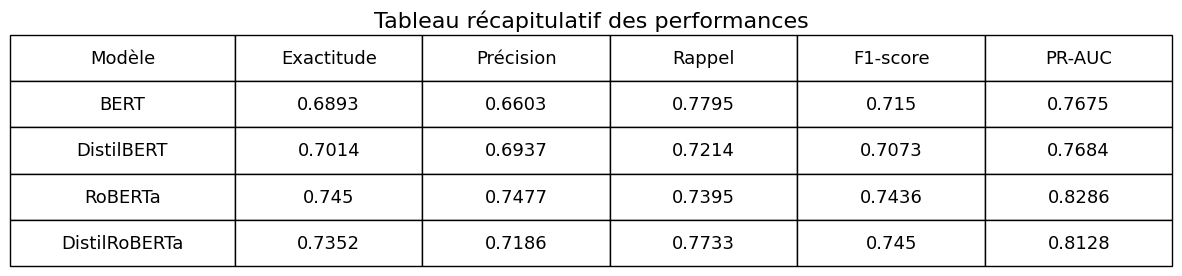

In [28]:
# Tableau récapitulatif des performances
deep_learning_results = pd.DataFrame({
    "Modèle": ["BERT", "DistilBERT", "RoBERTa", "DistilRoBERTa"],
    "Exactitude": [
        bert_metrics.loc[0, "Valeur"],
        distilbert_metrics.loc[0, "Valeur"],
        roberta_metrics.loc[0, "Valeur"],
        distilroberta_metrics.loc[0, "Valeur"]
    ],
    "Précision": [
        bert_metrics.loc[1, "Valeur"],
        distilbert_metrics.loc[1, "Valeur"],
        roberta_metrics.loc[1, "Valeur"],
        distilroberta_metrics.loc[1, "Valeur"]
    ],
    "Rappel": [
        bert_metrics.loc[2, "Valeur"],
        distilbert_metrics.loc[2, "Valeur"],
        roberta_metrics.loc[2, "Valeur"],
        distilroberta_metrics.loc[2, "Valeur"]
    ],
    "F1-score": [
        bert_metrics.loc[3, "Valeur"],
        distilbert_metrics.loc[3, "Valeur"],
        roberta_metrics.loc[3, "Valeur"],
        distilroberta_metrics.loc[3, "Valeur"]
    ],
    "PR-AUC": [
        bert_metrics.loc[4, "Valeur"],
        distilbert_metrics.loc[4, "Valeur"],
        roberta_metrics.loc[4, "Valeur"],
        distilroberta_metrics.loc[4, "Valeur"]
    ]
})

fig, ax = plt.subplots(figsize=(15, 3))
ax.axis("off")
table = ax.table(
    cellText=deep_learning_results.values,
    colLabels=deep_learning_results.columns,
    cellLoc="center",
    bbox=[0, 0, 1, 1],
    colWidths=[0.12, 0.10, 0.10, 0.10, 0.10, 0.10]
)
table.auto_set_font_size(False)
table.set_fontsize(13)
plt.title("Tableau récapitulatif des performances", fontsize=16)
plt.show()

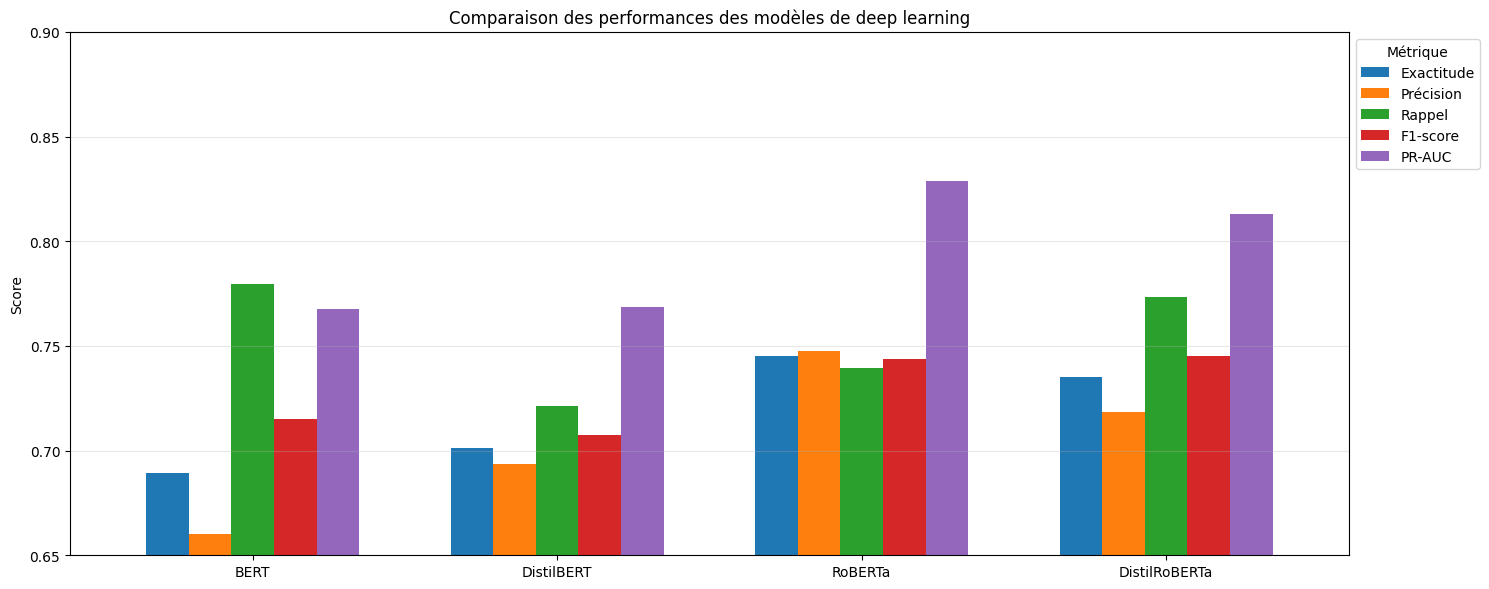

In [29]:
# Comparaison graphique des performances
comparison_results = deep_learning_results.copy()
metrics_to_plot = ["Exactitude", "Précision", "Rappel", "F1-score", "PR-AUC"]

comparison_results.set_index("Modèle")[metrics_to_plot].plot(
    kind="bar",
    figsize=(15, 6),
    width=0.7
)
plt.title("Comparaison des performances des modèles de deep learning")
plt.xlabel("")
plt.ylabel("Score")
plt.ylim(0.65, 0.9)
plt.xticks(rotation=0, ha="center")
plt.legend(
    title="Métrique",
    bbox_to_anchor=(1, 1),
    loc="upper left"
)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

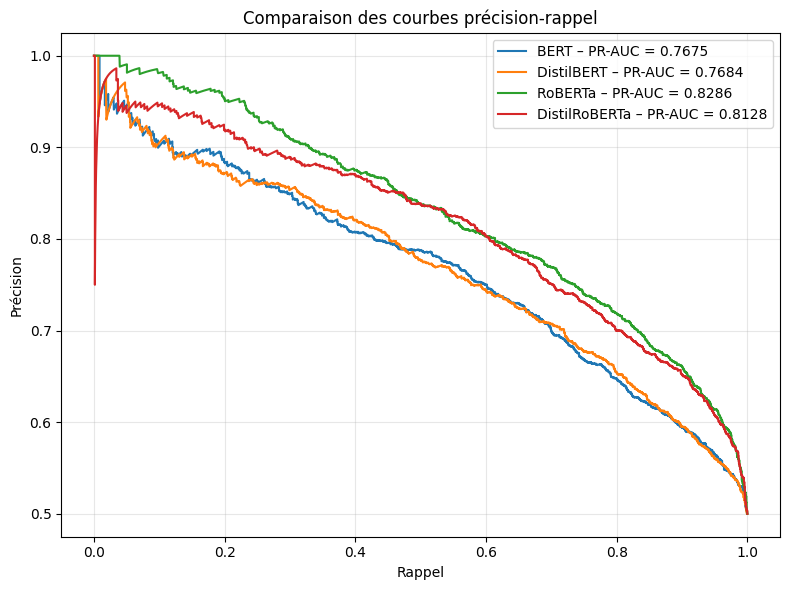

In [30]:
# Comparaison des courbes précision-rappel
plt.figure(figsize=(8, 6))
plt.plot(
    bert_recall_curve, bert_precision_curve,
    label=f"BERT – PR-AUC = {bert_pr_auc:.4f}"
)
plt.plot(
    distilbert_recall_curve, distilbert_precision_curve,
    label=f"DistilBERT – PR-AUC = {distilbert_pr_auc:.4f}"
)
plt.plot(
    roberta_recall_curve, roberta_precision_curve,
    label=f"RoBERTa – PR-AUC = {roberta_pr_auc:.4f}"
)
plt.plot(
    distilroberta_recall_curve, distilroberta_precision_curve,
    label=f"DistilRoBERTa – PR-AUC = {distilroberta_pr_auc:.4f}"
)
plt.xlabel("Rappel")
plt.ylabel("Précision")
plt.title("Comparaison des courbes précision-rappel")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Les quatre modèles présentent des performances globalement proches. RoBERTa se distingue par la meilleure précision (0,7477) et la meilleure PR-AUC (0,8286), tout en conservant un F1-score élevé de 0,7436. DistilRoBERTa obtient le meilleur F1-score (0,7450) et un rappel plus élevé, tandis que BERT présente le rappel le plus important (0,7795). Compte tenu de ses performances globales et de sa PR-AUC nettement supérieure, RoBERTa est retenu comme modèle de deep learning pour la suite des expérimentations sur le déséquilibre des classes. Les modèles distillés restent toutefois intéressants en raison de leur temps de fine-tuning plus faible.